In [9]:
!pip install hdbscan umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 10.1 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.3 MB/s  0:00:05m0:00:0100:01
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Created wheel for hdbscan: filename=hdbscan-0.8.40-cp312-cp312-linux_x86_64.whl size=4185982 sha256=0586c3403513ff7b084f04a4c368edcb3adf84163bc7d52b9dd0c3549d2d1ecb
  Stored in directory: /home/hasinthaka/.cache/pip/wheels/80/e7/bb/173ca0d8ce12718c4b5e6e01619c99653579b56969b97604b2
Successfully built hdbscan
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [umap-learn]6 [umap-learn]]


In [10]:
import pandas as pd
from sklearn.cluster import KMeans,DBSCAN
from hdbscan import HDBSCAN


In [2]:
data = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/AI Pattern Mining/Paper Mining/outputs/[25.09.12] - 02 - Prompt, Temperature, Embedding Model, Clustering changes/pattern_embeddings.csv")

In [3]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Pattern Name
0,-0.026390,0.016877,0.003469,-0.059432,0.000679,-0.007049,-0.003441,0.006716,0.005773,-0.004502,...,0.000156,0.005030,-0.020272,-0.005736,0.017508,-0.018598,-0.011882,0.009154,-0.006871,LLM-Augmented Knowledge Base
1,-0.022682,0.022629,-0.001960,-0.067257,-0.014537,-0.008264,-0.013734,0.020719,0.007014,-0.014342,...,-0.003781,-0.001719,-0.009078,-0.001407,0.013591,-0.020204,-0.013302,0.010415,-0.010209,LLM as Semantic Content Encoder
2,-0.024981,0.021741,0.003734,-0.071455,-0.012520,-0.001127,-0.007317,0.030100,0.006767,-0.007825,...,-0.009118,0.007417,-0.026991,-0.003931,0.005830,-0.011905,-0.008184,0.015207,-0.002978,Instruction Tuning for Recommendation
3,-0.009939,0.020262,0.005763,-0.075995,-0.015393,-0.010150,0.001580,0.017709,0.014028,-0.011873,...,0.008201,-0.000316,-0.019606,0.001669,0.006667,-0.010740,-0.017044,0.020824,-0.011099,LLM as Explainable Recommender
4,-0.013650,0.012573,0.001938,-0.070984,-0.010045,-0.003161,-0.007739,0.016244,0.006855,0.003499,...,0.003709,-0.000981,-0.017630,0.001765,0.004956,-0.004938,-0.008712,0.009176,-0.003024,LLM as Direct Recommender (via In-Context Lear...


In [4]:
embeddings = data.drop(labels=["Pattern Name"],axis=1)

### Checking Distance

In [5]:
from sklearn.metrics import pairwise_distances
import numpy as np

distances = pairwise_distances(embeddings)
print("Min distance:", distances.min())
print("Max distance:", distances.max())
print("Mean distance:", distances.mean())

Min distance: 0.0
Max distance: 0.751403258123237
Mean distance: 0.576608073121368


## KMeans Clustering

In [6]:
num_clusters = 50
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)


## DBSCAN Clustering

In [7]:
dbscan = DBSCAN(eps=0.12,min_samples=1, metric='cosine')
labels = dbscan.fit_predict(embeddings)
labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17,  9, 18,  4, 12, 19, 20, 21, 13,  0,  0,  0,  0,  0,  0, 22,
       23,  0,  0,  0,  0, 24,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, 25,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [18]:
dbscan = HDBSCAN(min_cluster_size=2, metric='euclidean')
labels = dbscan.fit_predict(embeddings)
labels

/home/hasinthaka/Documents/Projects/AI/AI Pattern Mining/Paper Mining/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/AI Pattern Mining/Paper Mining/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([-1, -1,  9,  9,  9, 14, -1,  9, 16, 15, -1,  7,  7,  7,  7, 12, 12,
       15, 10, -1,  6, -1, -1,  5, -1, -1,  6, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, 10, 16, 12, 12, -1, -1, 17, -1, -1, 17, 17, -1,
       -1, 17, -1, -1, -1, -1, -1, -1, -1, 12, -1, -1,  4, -1, 17, -1, -1,
       -1, -1, -1, -1,  8,  8, -1, 17, -1, 17, -1, 17, 10, 10,  5,  5, -1,
       15, -1, -1, -1,  2,  2,  5, -1, 17, -1, 12, -1, -1, -1, -1, -1,  2,
       -1, -1, 17, -1, -1, -1, -1, 14,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        3,  3,  3, 16, 15, -1, 10, 13, -1, 14, -1, 17, -1, 14, 14, 13, -1,
       -1, 16, 15, -1, 10, -1, 14, -1, -1, 11, 11, 11, -1, -1, -1, -1, 13,
       -1, -1,  5, -1, -1,  0, -1,  0,  0, -1,  0,  0, -1,  0,  1,  0, -1,
       -1,  0, -1,  0,  0,  0, -1, -1, -1, -1, -1, 16, -1, -1, -1, -1,  0,
       -1, 15,  6, -1,  4, -1, -1, 17, -1, -1, 13, 14, -1, -1, -1, 14, 14,
       -1, -1, -1, -1, -1, 17, -1, 14, -1, 14, 15, -1, -1, 17, -1, -1])

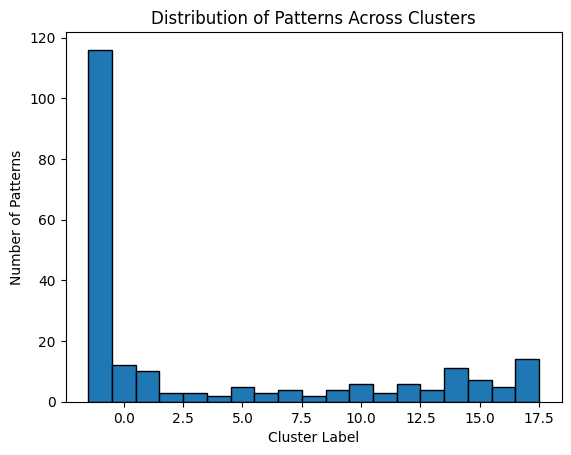

In [24]:
from matplotlib import pyplot as plt
plt.hist(labels, bins=np.arange(labels.min(), labels.max()+2)-0.5, edgecolor='black')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Patterns')
plt.title('Distribution of Patterns Across Clusters')
plt.show()

In [19]:
print("Clusters found:", len(set(labels)) - (1 if -1 in labels else 0))

Clusters found: 18


In [12]:
new_data = data["Pattern Name"]
new_data = new_data.to_frame()

In [13]:
new_data

,Pattern Name
0,LLM-Augmented Knowledge Base
1,LLM as Semantic Content Encoder
2,Instruction Tuning for Recommendation
3,LLM as Explainable Recommender
4,LLM as Direct Recommender (via In-Context Lear...
...,...
215,Reasoning Verification (Entailer)
216,Monte-Carlo Planning for Faithful Reasoning (F...
217,Retrieval-Augmented Reasoning
218,LLM as a Semantic Parser


In [14]:
new_data["cluster"]= labels

In [15]:
type(new_data)

pandas.core.frame.DataFrame

In [16]:
type(data)

pandas.core.frame.DataFrame

In [17]:
new_data

,Pattern Name,cluster
0,LLM-Augmented Knowledge Base,0
1,LLM as Semantic Content Encoder,0
2,Instruction Tuning for Recommendation,0
3,LLM as Explainable Recommender,0
4,LLM as Direct Recommender (via In-Context Lear...,0
...,...,...
215,Reasoning Verification (Entailer),0
216,Monte-Carlo Planning for Faithful Reasoning (F...,0
217,Retrieval-Augmented Reasoning,0
218,LLM as a Semantic Parser,0


In [27]:
num_clusters = len(set(labels))
new_data.to_json(f"/home/hasinthaka/Documents/Projects/AI/AI Pattern Mining/Paper Mining/outputs/[25.09.12] - 02 - Prompt, Temperature, Embedding Model, Clustering changes/patterns_with_{num_clusters}_clusters.json",index=False,indent=4,orient="records")